# PARCIAL 1 TAM (Teoría de Aprendizaje de Máquina)





## Ej 1 


Presente una infograf ́ıa en la que analice y compare las principales semejanzas y diferencias entre las arquitecturas densas, con-
volucionales, recurrentes y basadas en atenci  ́on (Transformers), utilizadas en aprendizaje profundo. La infograf ́ıa debe incluir (al
menos): (i) el modelo matem ́atico fundamental de cada arquitectura, (ii) un esquema ilustrativo de sus capas principales y (iii) sus
aplicaciones m ́as representativas

primero, veamos un skeleton de la teoría conceptual 

### Rutas de Aprendizaje Profundo: MLP · CNN · LSTM · Transformer


Cuatro familias procesan la misma tabla de features para predecir (x, y).


#### MLP (denso)



- Entrada: vector plano `n_features`
- Núcleo: Dense ReLU → salida lineal 2D
- Forte: tabular; bajo costo; baseline rápido
- Métricas: MAE, RMSE, R², MAPE

#### CNN1D




- Entrada: secuencia `(n_features, 1)`
- Núcleo: Conv1D pequeñas + GAP → Dense
- Forte: patrones locales en features ordenadas
- Métricas: MAE, RMSE, R², MAPE

#### LSTM




- Entrada: secuencia `(n_features, 1)`
- Núcleo: LSTM(64) → Dense
- Forte: dependencias secuenciales simples; comparación vs CNN/MLP
- Métricas: MAE, RMSE, R², MAPE



#### Transformer ligero


- Entrada: tokens = features
- Núcleo: proyección a embedding, MultiHeadAttention(2), FFN, GAP
- Forte: relaciones cruzadas entre features sin asumir orden fuerte
- Métricas: MAE, RMSE, R², MAPE


### Finalmente discutimos similitudes y diferencias:  

| Arquitectura | Modelo matemático (resumen) | Loss/Objetivo | Optimización típica | Uso recomendado | Escalabilidad |
|:--|:--|:--|:--|:--|:--|
| MLP denso | $$\hat{y} = f_\theta(x)$$ (Dense ReLU, salida 2D) | $$J = \tfrac{1}{2n}\,\lVert y-\hat{y}\rVert_2^2$$ | Adam (mini‑batch), EarlyStopping | Tabular; baseline rápido y barato | Excelente (GPU/CPU) |
| CNN1D | $$\hat{y} = f_\theta(\mathrm{Conv1D}(x)) + \mathrm{GAP} + \mathrm{Dense}$$ | $$\text{MSE}$$ | Adam; kernels 3–5 | Secuencias cortas de features ordenadas; patrones locales | Alta (conv ligera) |
| LSTM | $$\hat{y} = f_\theta(\mathrm{LSTM}(x)) + \mathrm{Dense}$$ | $$\text{MSE}$$ | Adam; dropout opcional | Dependencias secuenciales simples; comparación CNN/MLP | Media (menos paralelizable) |
| Transformer ligero | $$\hat{y} = f_\theta(\mathrm{MHA}(E x)) + \mathrm{FFN} + \mathrm{GAP}$$ | $$\text{MSE}$$ | Adam; heads=2–4, $$\mathrm{embed\_dim}=32{-}64$$ | Relaciones cruzadas entre features; sin asumir orden fuerte | Alta (atención pequeña) |


                                                                            MSE 

$$
J(\theta) = \frac{1}{2n}\sum_{i=1}^n \|y_i - \hat{y}_i\|_2^2
$$

Las cuatro familias (MLP/CNN/LSTM/Transformer) comparten el mismo objetivo (minimizar MSE sobre las coordenadas), pero difieren en cómo explotan la estructura de los features. MLP es el baseline más ligero y eficaz en tabular; CNN1D introduce inductiva local y mejora si hay orden en las variables; LSTM añade memoria, útil solo si existe dependencia secuencial clara; el Transformer ligero permite interacciones cruzadas entre features sin asumir orden rígido, ofreciendo mayor flexibilidad a costa de algo más de cómputo.

 En esta base tabular, MLP y Transformer suelen ser los más costo-eficientes; CNN1D/LSTM quedan como referencias para evaluar si existe ganancia al modelar orden o dependencia secuencial en los atributos.

Dejamos como base para crear una infografía como formato de entrega

## EJ 2

Finalmente, se presenta un analisis detallado del conjunto de datos disponible en https://www.kaggle.com/competitions/nfl-big-data-bowl-2026-prediction/overview. Incluyendo la descripcion de las variables de entrada y salida, el objetivo principal del concurso, un analisis
exploratorio basico, los procedimientos de codificacion de valores faltantes y variables categoricas, ası como las estrategias de
ingenierıa de caracterısticas —si aplican—. Luego, proporcione todos los detalles necesarios para comprender, interpretar y
analizar adecuadamente el conjunto de datos.

Utilizando un esquema de validacion hold-out con una partici  ́on del 60 % para entrenamiento, 20 % para validacion y 20 %
para evaluacion del rendimiento, intentamos comparar el rendimiento de los modelos descritos en el punto anterior, empleando el conjunto de datos de entrenamiento disponible en el dataset.

 Finalmente, presentamos los rendimientos promedio obtenidos sobre el conjunto de evaluacion, junto con su
respectiva desviacion est ́andar, empleando las siguientes metricas de desempeno: MAE, MSE, R2 y MAPE

### entorno de desarrollo


primero es necesario configurar nuestro  entorno, comenzando por la importancion de las librerias y dependencias necesarias para este caso, una vez instaladas en el entorno

In [55]:
import numpy as np
import pandas as pd
import sys

import os
import gdown 
import zipfile 
from scipy import stats
# Set the default style for seaborn
import seaborn as sns
sns.set(style="whitegrid")      


import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.display import display, Image
import sklearn 



import time
import warnings 

    
# Librerías ML CPU
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelos CPU
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
#LASSO 
from sklearn.linear_model import Lasso

# SVR
from sklearn.svm import SVR
# BR 
from sklearn.linear_model import BayesianRidge
# Ridge
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Ridge
# ELASTIC NET
from sklearn.linear_model import ElasticNet
# GBR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
# RF
from sklearn.ensemble import RandomForestRegressor
# SGD

from sklearn.linear_model import SGDRegressor

# GPR 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# Optuna para bayesian optimization
import optuna

# tensor flow 
import tensorflow as Tf


from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils.validation import check_is_fitted

# Configuración de gráficas
sns.set(style='whitegrid')

# Crear carpetas si no existen
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs("./results/models", exist_ok=True)

# models 
import joblib
from datetime import datetime




activar la memory growth es opcional (pero debe hacerse antes de crear tensores)

In [56]:
print('Python:', sys.version.splitlines()[0])
print('TensorFlow version:', Tf.__version__)
print('TF built with CUDA:', Tf.test.is_built_with_cuda())

cuda_visible = os.environ.get('CUDA_VISIBLE_DEVICES', 'No establecido')
print('\nCUDA_VISIBLE_DEVICES:', cuda_visible)

gpus = Tf.config.list_physical_devices('GPU')
print('\nGPUs físicas encontradas:', len(gpus))
for i, g in enumerate(gpus):
    print(f'  GPU {i}:', g)

if len(gpus) == 0:
    print('\nNo se detectaron GPUs en TensorFlow. Verifica:')
    print('1. nvidia-smi muestra la GPU')
    print('2. Las DLLs de CUDA están en el PATH')
    print('3. La versión de CUDA es compatible con TF 2.10')

for gpu in gpus:
    try:
        Tf.config.experimental.set_memory_growth(gpu, True)
        print('\nMemory growth activado para', gpu)
    except Exception as e:
        print('\nNo se pudo activar memory growth para', gpu, '->', e)


Python: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
TensorFlow version: 2.10.0
TF built with CUDA: True

CUDA_VISIBLE_DEVICES: No establecido

GPUs físicas encontradas: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Memory growth activado para PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


una vez configurada la GPU, procedemos a visualizar su configuración 

In [57]:
cuda_visible = os.environ.get('CUDA_VISIBLE_DEVICES', 'establecido')
print('\nCUDA_VISIBLE_DEVICES:', cuda_visible)



CUDA_VISIBLE_DEVICES: establecido


In [58]:
gpus = Tf.config.list_physical_devices('GPU')
assert gpus, "GPU no visible para TensorFlow."
for g in gpus:
    Tf.config.experimental.set_memory_growth(g, True)    # evita que TF reserve toda la VRAM de golpe


usamos el mixed precision para reducir RAM/VRAM


In [59]:
Tf.keras.mixed_precision.set_global_policy("mixed_float16")

es importante configurar matplotlib

In [60]:
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


también, creamos una carpeta para guardar los resultados y otra para la importación de datos

In [61]:
try:
  os.mkdir('results')
  os.mkdir('data')
  print('carpetas creadas en el entorno de trabajo')
except:
  print("Carpetas ya creadas en el entorno de trabajo")

Carpetas ya creadas en el entorno de trabajo


finalmente, los warnings y semillas

In [62]:
warnings.filterwarnings(action="ignore", message="^internal gelsd")

np.random.seed(42)



###  importación y lectura  de los datos: 


#### usaremos gdown para descargar desde el drive personal (evitando conflictos de permiso) y procederemos con zip file para descomprimir el dataset

In [63]:

# Download dataset from personal Google Drive

# https://drive.google.com/file/d/1dqeoLxOrYAf0-JS2sf5sDHxxIRuX8PjG/view?usp=sharing
fileID = "1dqeoLxOrYAf0-JS2sf5sDHxxIRuX8PjG"
url = f"https://drive.google.com/uc?id={fileID}"
output = "data/NFLdataset.zip"
gdown.download(url, output, quiet=False, fuzzy=True, use_cookies=False)
  
!dir

Downloading...
From (original): https://drive.google.com/uc?id=1dqeoLxOrYAf0-JS2sf5sDHxxIRuX8PjG
From (redirected): https://drive.google.com/uc?id=1dqeoLxOrYAf0-JS2sf5sDHxxIRuX8PjG&confirm=t&uuid=b313adf2-321e-4298-bc78-5072b45ac31a
To: a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\devContent\tests\P2\data\NFLdataset.zip
100%|██████████| 107M/107M [00:05<00:00, 19.1MB/s] 


 Volume in drive A is dataOs
 Volume Serial Number is 42ED-9D11

 Directory of a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\devContent\tests\P2

02/12/2025  16:26    <DIR>          .
02/12/2025  15:47    <DIR>          ..
02/12/2025  16:51    <DIR>          backup
02/12/2025  17:00    <DIR>          data
02/12/2025  16:29             9,664 dl_models_after_premodelado.py
02/12/2025  16:29             3,770 dl_models_README.md
02/12/2025  15:47    <DIR>          docs
02/12/2025  16:03    <DIR>          ExtractedDataset
02/12/2025  17:00         1,884,729 NFLModelFinalVersion.ipynb
02/12/2025  16:12    <DIR>          results
               3 File(s)      1,898,163 bytes
               7 Dir(s)  338,121,539,584 bytes free


#### procedemos descomprimiendo el dataset descargado mediante drive usando ZIPFILE

In [64]:
'''
with zipfile.ZipFile("data/NFLdataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data/ExtractedDataset")
'''
''' second version 
import shutil
shutil.unpack_archive("dataset.zip", "ExtractedDataset", "zip")
'''


import shutil
shutil.unpack_archive("data/NFLdataset.zip", "ExtractedDataset", "zip")

es importante recoerdar ignorar estas carpetas en nuestro .gitignore 

#### ahora, procesamos la información

In [65]:
data_path = 'ExtractedDataset/train'# Ruta base donde se almacenan los archivos CSV



procedemos leyendo los datos de seguimiento antes de que el balón se lance 

In [66]:
input_dfs = []
for week in range(1, 19):
    fname = os.path.join(data_path, f'input_2023_w{week:02d}.csv')
    if os.path.exists(fname):
        input_dfs.append(pd.read_csv(fname))
        print(f'Archivo {fname} cargado. Observaciones: {input_dfs[-1].shape[0]}')
    else:
        print(f'  No se encontró {fname}')

input_df = pd.concat(input_dfs, ignore_index=True) # The input df is a pandas dataframe with all weeks data 

Archivo ExtractedDataset/train\input_2023_w01.csv cargado. Observaciones: 285714
Archivo ExtractedDataset/train\input_2023_w02.csv cargado. Observaciones: 288586
Archivo ExtractedDataset/train\input_2023_w03.csv cargado. Observaciones: 297757
Archivo ExtractedDataset/train\input_2023_w04.csv cargado. Observaciones: 272475
Archivo ExtractedDataset/train\input_2023_w05.csv cargado. Observaciones: 254779
Archivo ExtractedDataset/train\input_2023_w06.csv cargado. Observaciones: 270676
Archivo ExtractedDataset/train\input_2023_w07.csv cargado. Observaciones: 233597
Archivo ExtractedDataset/train\input_2023_w08.csv cargado. Observaciones: 281011
Archivo ExtractedDataset/train\input_2023_w09.csv cargado. Observaciones: 252796
Archivo ExtractedDataset/train\input_2023_w10.csv cargado. Observaciones: 260372
Archivo ExtractedDataset/train\input_2023_w11.csv cargado. Observaciones: 243413
Archivo ExtractedDataset/train\input_2023_w12.csv cargado. Observaciones: 294940
Archivo ExtractedDataset/tra

De igual forma para los datos de salida, que describen la posición del jugador una vez el pase se realizó 


In [67]:
output_dfs = []
for week in range(1, 19):
    fname = os.path.join(data_path, f'output_2023_w{week:02d}.csv')
    if os.path.exists(fname):
        output_dfs.append(pd.read_csv(fname))
        print(f'Archivo {fname} cargado. Observaciones: {input_dfs[-1].shape[0]}')

    else:
        print(f'  No se encontró {fname}')

if output_dfs:
    output_df = pd.concat(output_dfs, ignore_index=True)
else:
    output_df = pd.DataFrame()



Archivo ExtractedDataset/train\output_2023_w01.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w02.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w03.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w04.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w05.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w06.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w07.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w08.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w09.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w10.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w11.csv cargado. Observaciones: 254917
Archivo ExtractedDataset/train\output_2023_w12.csv cargado. Observaciones: 254917
Archivo Extracte

In [68]:
print('\nResumen de dimensiones:')
print('input data:', input_df.shape)
print('output data:', output_df.shape)


Resumen de dimensiones:
input data: (4880579, 23)
output data: (562936, 6)


### EDA

mostramos las primeras filas


In [69]:
display(input_df.head())

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


también información general de tipos y valores nulos

In [70]:
print(input_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880579 entries, 0 to 4880578
Data columns (total 23 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   game_id                   int64  
 1   play_id                   int64  
 2   player_to_predict         bool   
 3   nfl_id                    int64  
 4   frame_id                  int64  
 5   play_direction            object 
 6   absolute_yardline_number  int64  
 7   player_name               object 
 8   player_height             object 
 9   player_weight             int64  
 10  player_birth_date         object 
 11  player_position           object 
 12  player_side               object 
 13  player_role               object 
 14  x                         float64
 15  y                         float64
 16  s                         float64
 17  a                         float64
 18  dir                       float64
 19  o                         float64
 20  num_frames_output       

de igual forma, vemos la distribución de las variables categóricas


In [71]:
cat_cols = ['player_position', 'player_side', 'player_role', 'player_to_predict', 'play_direction' , 'player_name' ,'player_height' , 'player_birth_date' ]
for col in cat_cols:
    print(f"\nDistribución de {col}:")
    print(input_df[col].value_counts().head(10))


Distribución de player_position:
player_position
WR     1063660
CB     1056888
FS      476865
TE      417146
QB      401007
SS      392421
RB      314918
ILB     295593
OLB     207429
MLB     199983
Name: count, dtype: int64

Distribución de player_side:
player_side
Defense    2662657
Offense    2217922
Name: count, dtype: int64

Distribución de player_role:
player_role
Defensive Coverage    2662657
Other Route Runner    1424243
Targeted Receiver      396914
Passer                 396765
Name: count, dtype: int64

Distribución de player_to_predict:
player_to_predict
False    3577139
True     1303440
Name: count, dtype: int64

Distribución de play_direction:
play_direction
right    2459074
left     2421505
Name: count, dtype: int64

Distribución de player_name:
player_name
Cameron Sutton      13641
Jared Goff          13517
Dak Prescott        13400
Darious Williams    13343
Patrick Mahomes     13299
Sam Howell          13203
Asante Samuel       13003
Pat Surtain II      12886
Rayshawn

podemos observar como la distribución de la posición del jugador, o su rol, no pueden ser definidas de maneras específicas, de aqui parte pensar en una estrategia para codificar estas variables NO ordinales



Y también las estadísticas básicas de variables numéricas

In [72]:
numeric_features = ['x','y','s','a','o','dir','player_weight','absolute_yardline_number','ball_land_x', 'ball_land_y']
display(input_df[numeric_features].describe())


,x,y,s,a,o,dir,player_weight,absolute_yardline_number,ball_land_x,ball_land_y
count,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06,4.880579e+06
mean,6.050074e+01,2.681190e+01,3.019878e+00,2.118335e+00,1.815366e+02,1.804972e+02,2.112783e+02,6.055045e+01,6.051581e+01,2.663766e+01
std,2.348919e+01,1.000620e+01,2.227939e+00,1.415794e+00,9.800912e+01,1.007162e+02,2.217747e+01,2.305935e+01,2.529643e+01,1.543814e+01
min,4.100000e-01,6.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.530000e+02,1.100000e+01,-5.260000e+00,-3.910000e+00
25%,4.263000e+01,1.899000e+01,1.090000e+00,1.010000e+00,9.174000e+01,9.091000e+01,1.950000e+02,4.100000e+01,4.261000e+01,1.330000e+01
50%,6.041000e+01,2.685000e+01,2.720000e+00,1.920000e+00,1.801400e+02,1.795600e+02,2.070000e+02,6.100000e+01,6.051000e+01,2.647000e+01
75%,7.823000e+01,3.462000e+01,4.620000e+00,3.040000e+00,2.715800e+02,2.708300e+02,2.250000e+02,8.000000e+01,7.847000e+01,3.987000e+01
max,1.198600e+02,5.288000e+01,1.253000e+01,1.712000e+01,3.600000e+02,3.600000e+02,3.580000e+02,1.090000e+02,1.258500e+02,5.733000e+01


procedemos visualizando las distribuciones

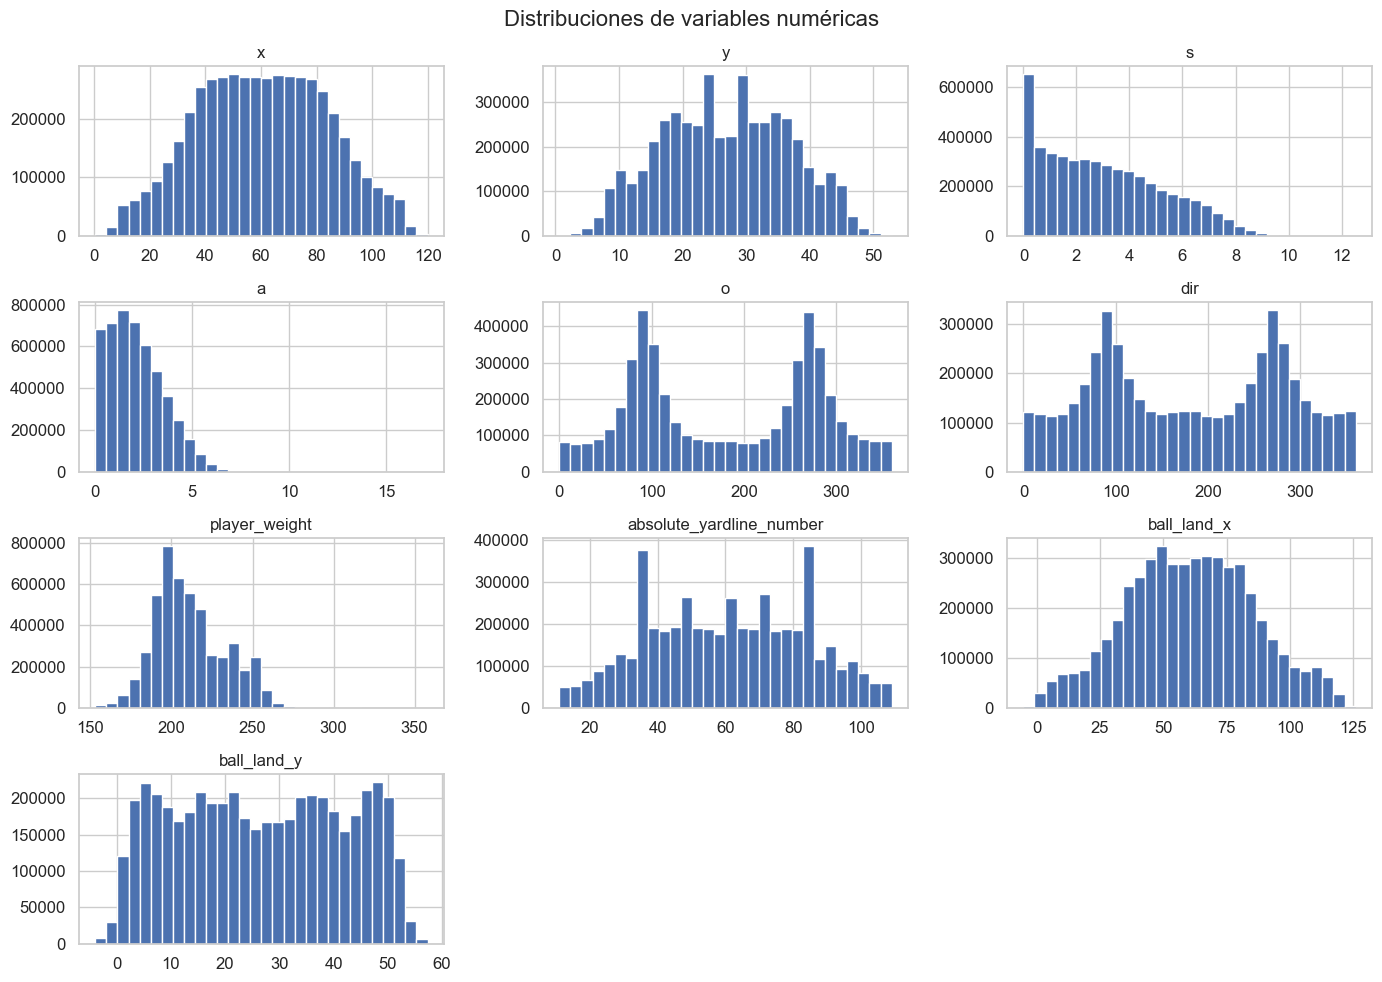

In [73]:
input_df[numeric_features].hist(bins=30, figsize=(14, 10))
plt.suptitle('Distribuciones de variables numéricas', fontsize=16)
plt.tight_layout()
plt.savefig('results/numeric_distributions.png', dpi=300)
plt.show()

veamos una tabla de frecuencia simples para nuestras categóricas

In [74]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(input_df[col].value_counts())


--- player_position ---
player_position
WR     1063660
CB     1056888
FS      476865
TE      417146
QB      401007
SS      392421
RB      314918
ILB     295593
OLB     207429
MLB     199983
FB       19584
DE       16932
S        13764
DT        3139
NT        1090
T           83
LB          31
P           23
K           23
Name: count, dtype: int64

--- player_side ---
player_side
Defense    2662657
Offense    2217922
Name: count, dtype: int64

--- player_role ---
player_role
Defensive Coverage    2662657
Other Route Runner    1424243
Targeted Receiver      396914
Passer                 396765
Name: count, dtype: int64

--- player_to_predict ---
player_to_predict
False    3577139
True     1303440
Name: count, dtype: int64

--- play_direction ---
play_direction
right    2459074
left     2421505
Name: count, dtype: int64

--- player_name ---
player_name
Cameron Sutton      13641
Jared Goff          13517
Dak Prescott        13400
Darious Williams    13343
Patrick Mahomes     13299
     

tambien podemos visualizarlo con countplots en una rejilla :

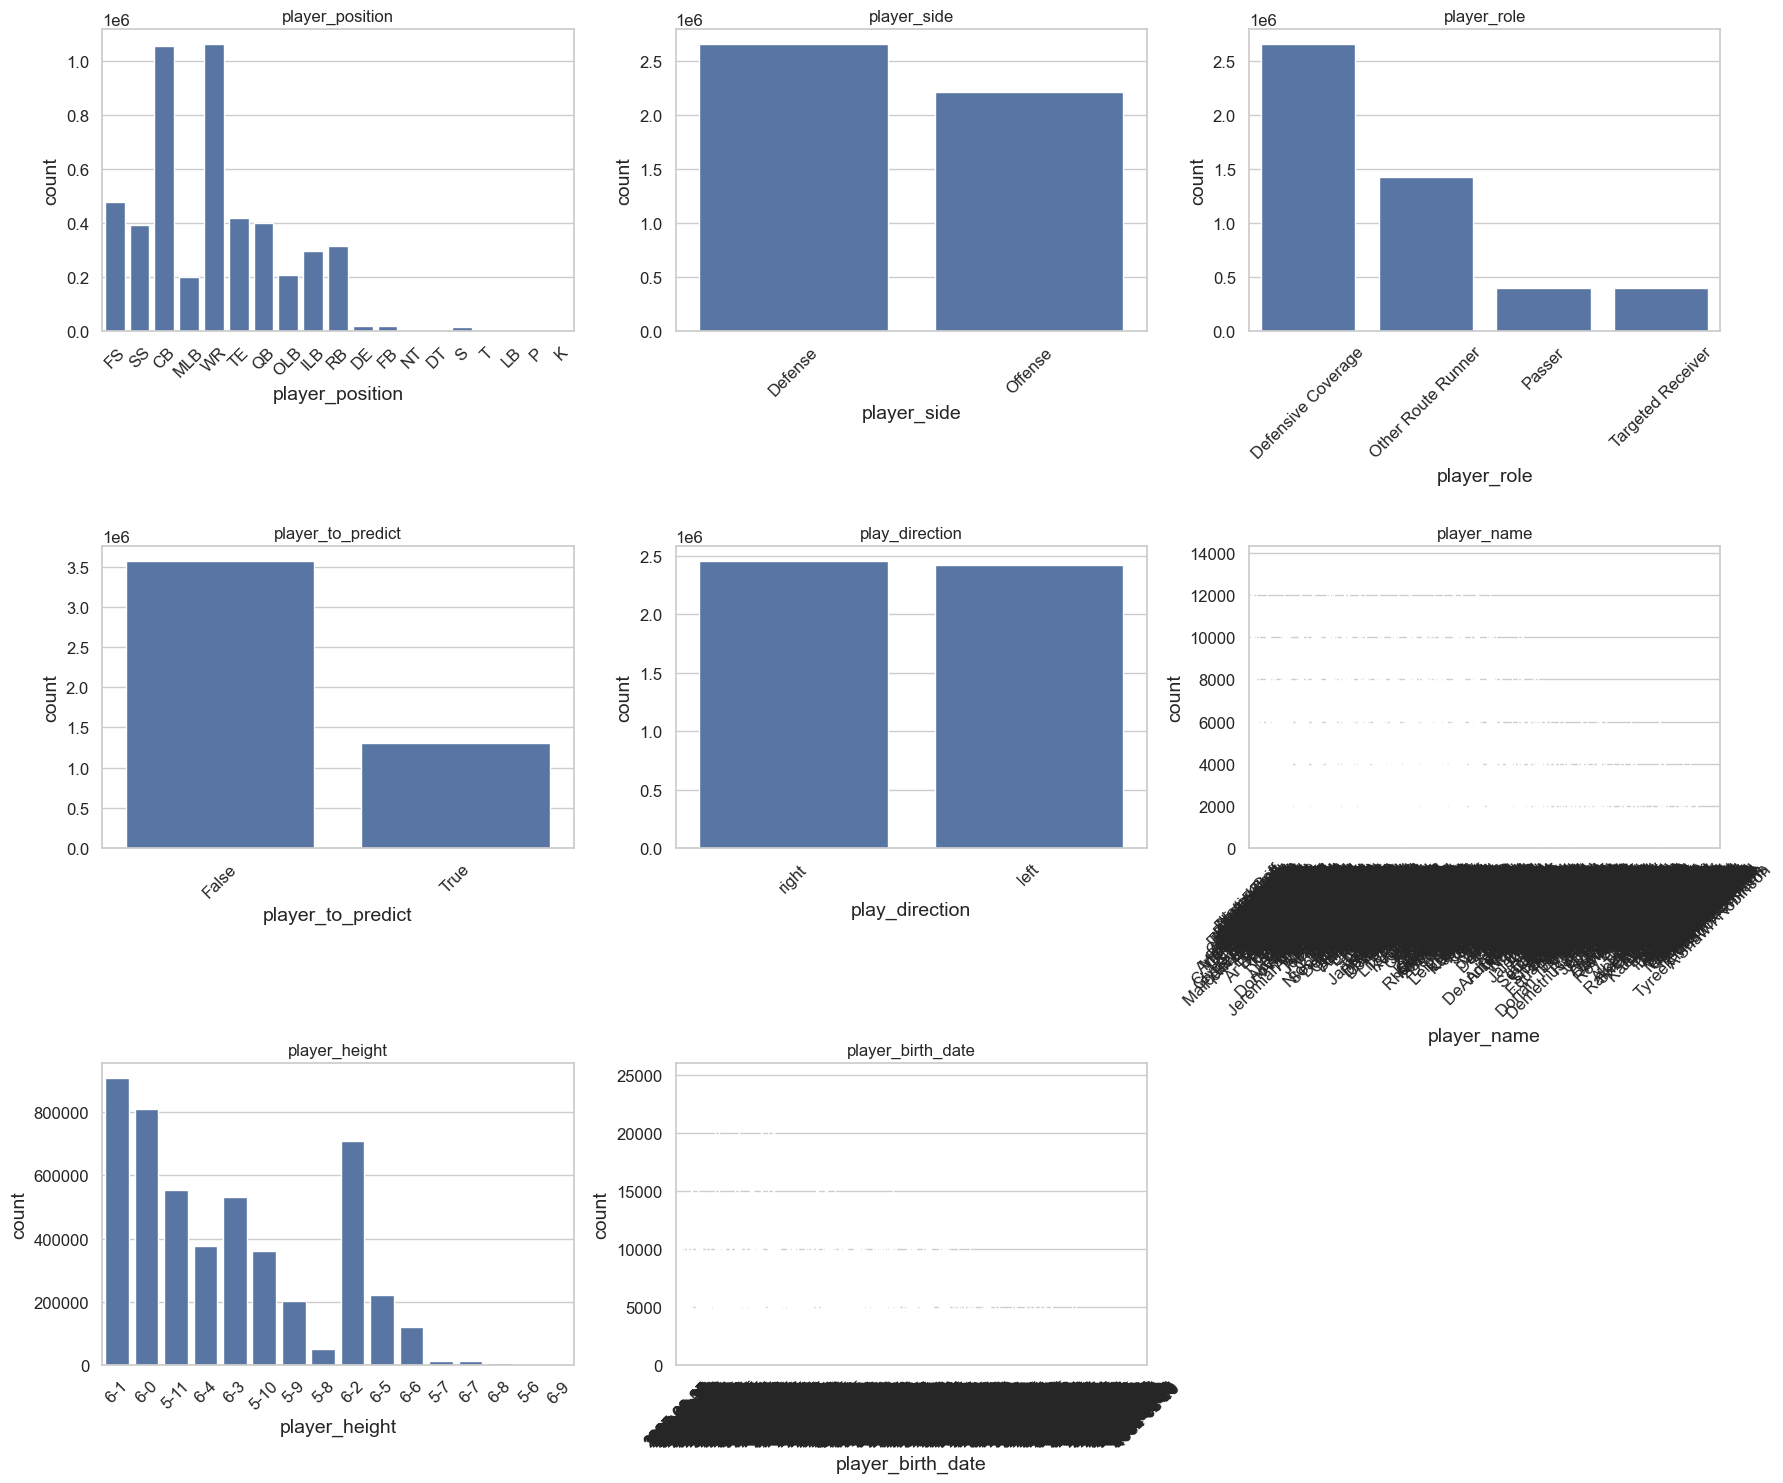

In [75]:
n = len(cat_cols)
fig, axes = plt.subplots(nrows=(n // 3) + 1, ncols=3, figsize=(18, 5 * ((n // 3) + 1)))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=input_df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

de aqui, puede ser interesante ver un mapa de calor : 

e.g, como se relaciona la posición del jugador con su rol? 

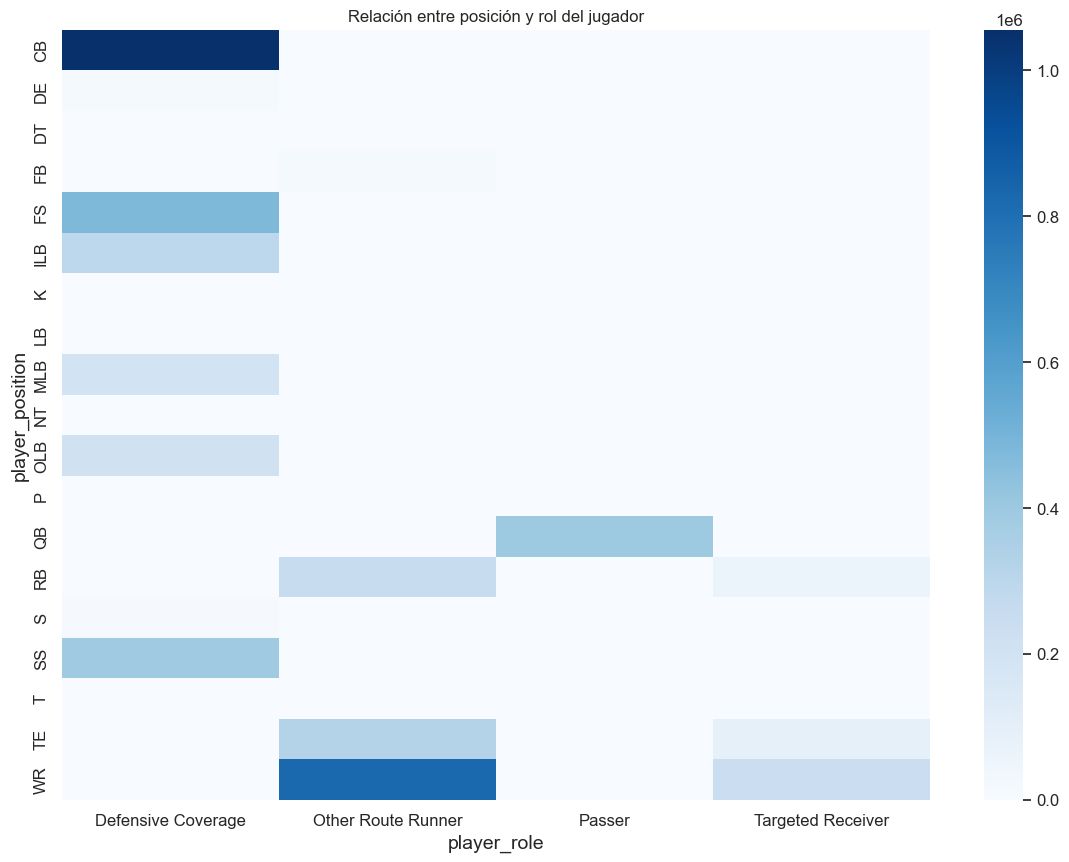

In [76]:
cross = pd.crosstab(input_df['player_position'], input_df['player_role'])

plt.figure(figsize=(14, 10))
sns.heatmap(cross, cmap="Blues", annot=False)
plt.title("Relación entre posición y rol del jugador")
plt.show()

de igual forma, es importante realizar la matriz de correlación para las numéricas:

In [77]:
corr_matrix = input_df[numeric_features].corr()


y visualizarla

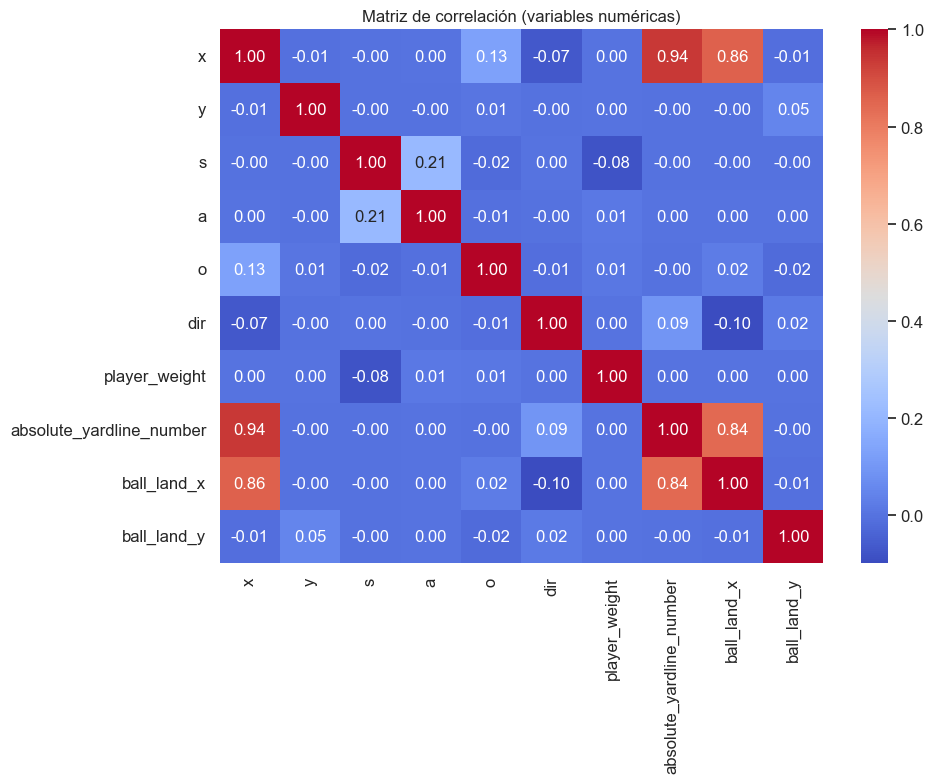

In [78]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.savefig('results/correlation_matrix.png', dpi=300) # save figure 
plt.show()


podemos ver que existe un bloque de variables redundantes:

- x

- absolute_yardline_number

Estas  contienen la misma información espacial en el eje longitudinal.

de aqui, podemos inferir que una buena estrategia puede ser realizar un muestreo estratificado

### preprocesamiento

una vez vista las distribuciones de las variables correlacionadas, podemos realizar una ingeniería de características con el fin de ayudar a la interpretabilidad de los modelos

e.g, es apta la conversión de la altura 

In [79]:
def parse_height(h):
    if isinstance(h, str) and '-' in h:
        ft, inch = h.split('-')
        return int(ft) * 12 + int(inch)
    return np.nan


aplicamos conversión de altura al data set

In [80]:

input_df['player_height'] = input_df['player_height'].apply(parse_height)


de igual manera, podemos calcular edad del jugador (en años) usando una fecha de referencia


In [81]:
input_df['player_birth_date'] = pd.to_datetime(input_df['player_birth_date'], errors='coerce')
reference_date = pd.to_datetime('2025-11-19')
input_df['age'] = (reference_date - input_df['player_birth_date']).dt.days / 365.25

ahora, procedemos a definir las listas de variables  categóricas y numéricas nuevamente al aplicar su respectiva ingeniería 

In [82]:
numerical_features = ['x','y','s','a','o','dir','player_weight','absolute_yardline_number','ball_land_x', 'ball_land_y' , 'player_height', 'age' ]


In [83]:
categorical_features = ['player_position', 'player_side', 'player_role', 'play_direction']


una vez realizada la distinción de nuestras variables, podemos definir el preprocesador para columnas numéricas y categóricas

comenzando con el preporcesador para las numéricas

In [84]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

de igual forma para las categóricas

aquí, utilizamos codificación one HOT ENCODER, dado la no ordinalidad de nuestras variables 

In [85]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
])

finalmente, obtenemos nuestro preprocesador con ayuda de columnTransformer

In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


aqui, procedemos a preparar los datos para nuestros diferentes modelos de aprendizaje

In [87]:
input_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880579 entries, 0 to 4880578
Data columns (total 24 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   game_id                   int64         
 1   play_id                   int64         
 2   player_to_predict         bool          
 3   nfl_id                    int64         
 4   frame_id                  int64         
 5   play_direction            object        
 6   absolute_yardline_number  int64         
 7   player_name               object        
 8   player_height             int64         
 9   player_weight             int64         
 10  player_birth_date         datetime64[ns]
 11  player_position           object        
 12  player_side               object        
 13  player_role               object        
 14  x                         float64       
 15  y                         float64       
 16  s                         float64       
 17  a       

In [88]:
output_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562936 entries, 0 to 562935
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   game_id   562936 non-null  int64  
 1   play_id   562936 non-null  int64  
 2   nfl_id    562936 non-null  int64  
 3   frame_id  562936 non-null  int64  
 4   x         562936 non-null  float64
 5   y         562936 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 25.8 MB


comenzando por la definicion de las variables de interés (objetivo a predecir)

In [89]:
target_cols = ['x', 'y']

de igual manera, generamos un merge con los ID de la jugada a predecir con el fin de enrutar correctamente. Es importante notar que esta estructura se toma de la salida 

In [90]:
 
merge_cols = ['game_id', 'play_id', 'nfl_id', 'frame_id']



finalmente, realizamos una copia de nuestro dataset

In [91]:

data_full = input_df.merge(
    output_df[merge_cols + target_cols], # enrutar con el frame especifico a predecir 
    on=merge_cols, # unir por las columnas clave 
    how='inner',
    suffixes=('', '_out')  # deja las features sin sufijo y marca los targets
)


In [92]:
data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560426 entries, 0 to 560425
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   game_id                   560426 non-null  int64         
 1   play_id                   560426 non-null  int64         
 2   player_to_predict         560426 non-null  bool          
 3   nfl_id                    560426 non-null  int64         
 4   frame_id                  560426 non-null  int64         
 5   play_direction            560426 non-null  object        
 6   absolute_yardline_number  560426 non-null  int64         
 7   player_name               560426 non-null  object        
 8   player_height             560426 non-null  int64         
 9   player_weight             560426 non-null  int64         
 10  player_birth_date         560426 non-null  datetime64[ns]
 11  player_position           560426 non-null  object        
 12  pl

comencemos una caracterizacions de los datos para su posterior aprendizaje


podemos separar las características (X) de las etiquetas (y)

In [93]:
dataToPredict = ['x_out', 'y_out']

finalente, creamos nuestra entrada con las variables de entrenamiento, SIN nuestra variable a predecir, pues esta irá en la salida

In [94]:
X = data_full[numerical_features + categorical_features]
y = data_full[dataToPredict] 

In [95]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560426 entries, 0 to 560425
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   x                         560426 non-null  float64
 1   y                         560426 non-null  float64
 2   s                         560426 non-null  float64
 3   a                         560426 non-null  float64
 4   o                         560426 non-null  float64
 5   dir                       560426 non-null  float64
 6   player_weight             560426 non-null  int64  
 7   absolute_yardline_number  560426 non-null  int64  
 8   ball_land_x               560426 non-null  float64
 9   ball_land_y               560426 non-null  float64
 10  player_height             560426 non-null  int64  
 11  age                       560426 non-null  float64
 12  player_position           560426 non-null  object 
 13  player_side               560426 non-null  o

vemos como la matriz de caracterísiticas, UNICAMENTE presenta las correlaciones y variables de interés para entrenar nuestro modelo 

In [96]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560426 entries, 0 to 560425
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   x_out   560426 non-null  float64
 1   y_out   560426 non-null  float64
dtypes: float64(2)
memory usage: 8.6 MB


de igual manera, para la matriz de salida, cuyas unicas columnas son nuestra posición a pronosticar 

ahora, realizamos la particion del conjunto de datos (hold out)

60 % entrenamiento


In [97]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size= 0.6,  test_size=0.4, random_state=42)

In [98]:
X_train.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 336255 entries, 221511 to 121958
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   x                         336255 non-null  float64
 1   y                         336255 non-null  float64
 2   s                         336255 non-null  float64
 3   a                         336255 non-null  float64
 4   o                         336255 non-null  float64
 5   dir                       336255 non-null  float64
 6   player_weight             336255 non-null  int64  
 7   absolute_yardline_number  336255 non-null  int64  
 8   ball_land_x               336255 non-null  float64
 9   ball_land_y               336255 non-null  float64
 10  player_height             336255 non-null  int64  
 11  age                       336255 non-null  float64
 12  player_position           336255 non-null  object 
 13  player_side               336255 non-null  o

validamos que el 60% de 560.4256 es 336.255 muestras, continuando asi con la divisón para validación y prueba

In [99]:
X_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 224171 entries, 25988 to 121864
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   x                         224171 non-null  float64
 1   y                         224171 non-null  float64
 2   s                         224171 non-null  float64
 3   a                         224171 non-null  float64
 4   o                         224171 non-null  float64
 5   dir                       224171 non-null  float64
 6   player_weight             224171 non-null  int64  
 7   absolute_yardline_number  224171 non-null  int64  
 8   ball_land_x               224171 non-null  float64
 9   ball_land_y               224171 non-null  float64
 10  player_height             224171 non-null  int64  
 11  age                       224171 non-null  float64
 12  player_position           224171 non-null  object 
 13  player_side               224171 non-null  ob

20 % validación, 20 % prueba

tomamos el 40% restante de X,Y_temp para crear nuestra validación y testeo con el 50% de 224171 

In [100]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp , test_size=0.5, random_state=42)

In [101]:
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112085 entries, 21798 to 323838
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   x                         112085 non-null  float64
 1   y                         112085 non-null  float64
 2   s                         112085 non-null  float64
 3   a                         112085 non-null  float64
 4   o                         112085 non-null  float64
 5   dir                       112085 non-null  float64
 6   player_weight             112085 non-null  int64  
 7   absolute_yardline_number  112085 non-null  int64  
 8   ball_land_x               112085 non-null  float64
 9   ball_land_y               112085 non-null  float64
 10  player_height             112085 non-null  int64  
 11  age                       112085 non-null  float64
 12  player_position           112085 non-null  object 
 13  player_side               112085 non-null  ob

In [102]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112086 entries, 515003 to 350571
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   x                         112086 non-null  float64
 1   y                         112086 non-null  float64
 2   s                         112086 non-null  float64
 3   a                         112086 non-null  float64
 4   o                         112086 non-null  float64
 5   dir                       112086 non-null  float64
 6   player_weight             112086 non-null  int64  
 7   absolute_yardline_number  112086 non-null  int64  
 8   ball_land_x               112086 non-null  float64
 9   ball_land_y               112086 non-null  float64
 10  player_height             112086 non-null  int64  
 11  age                       112086 non-null  float64
 12  player_position           112086 non-null  object 
 13  player_side               112086 non-null  o

finalmente, podemos ver el tamaño de los sets

In [103]:
print('Tamaños de los subconjuntos:')
print('Train :', X_train.shape)
print('Val   :', X_val.shape)
print('Test  :', X_test.shape)


Tamaños de los subconjuntos:
Train : (336255, 16)
Val   : (112085, 16)
Test  : (112086, 16)


ie, trabajaremos con 16 variables que presentan una correlación o fuerte relación 

procedamos con el modelado

### pre modelado

### Modelado deep learning (posterior al pre modelado)

Se reutiliza el preprocesador (imputación mediana + escalado para numéricas, moda + one-hot para categóricas) para dejar la base lista para redes neuronales. Las entradas son `numerical_features + categorical_features` y la salida continúa siendo `['x_out', 'y_out']`. El objetivo es mantener bajo costo y documentar cada arquitectura solicitada en el Parcial 2.


In [104]:
# Ajustamos el preprocesador y generamos matrices listas para Keras
preprocessor_dl = preprocessor  # reutiliza la misma configuración definida arriba
preprocessor_dl.fit(X_train)

X_train_proc = preprocessor_dl.transform(X_train)
X_val_proc = preprocessor_dl.transform(X_val)
X_test_proc = preprocessor_dl.transform(X_test)

# Convertir a matrices densas y tipo float32
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_val_proc = X_val_proc.toarray()
    X_test_proc = X_test_proc.toarray()

X_train_proc = X_train_proc.astype('float32')
X_val_proc = X_val_proc.astype('float32')
X_test_proc = X_test_proc.astype('float32')

y_train_proc = y_train[['x_out', 'y_out']].to_numpy(dtype='float32')
y_val_proc = y_val[['x_out', 'y_out']].to_numpy(dtype='float32')
y_test_proc = y_test[['x_out', 'y_out']].to_numpy(dtype='float32')

# Submuestreo opcional para reducir costo (ajusta quick_frac=1.0 para entrenamiento completo)
quick_frac = 0.02
if 0 < quick_frac < 1:
    n = int(len(X_train_proc) * quick_frac)
    idx = np.random.permutation(len(X_train_proc))[:max(1000, n)]
    X_train_dl = X_train_proc[idx]
    y_train_dl = y_train_proc[idx]
else:
    X_train_dl = X_train_proc
    y_train_dl = y_train_proc

X_val_dl = X_val_proc
X_test_dl = X_test_proc
y_val_dl = y_val_proc
y_test_dl = y_test_proc

np.savez('data/prep_data_dl.npz',
         X_train=X_train_proc,
         y_train=y_train_proc,
         X_val=X_val_proc,
         y_val=y_val_proc,
         X_test=X_test_proc,
         y_test=y_test_proc)

print(f'Datos DL -> train {X_train_dl.shape}, val {X_val_dl.shape}, test {X_test_dl.shape}')
print(f'NaNs en X_train_dl: {np.isnan(X_train_dl).sum()} | NaNs en y_train_dl: {np.isnan(y_train_dl).sum()}')


Datos DL -> train (6725, 35), val (112085, 35), test (112086, 35)
NaNs en X_train_dl: 0 | NaNs en y_train_dl: 0


#### Arquitecturas y configuración de entrenamiento

- `MLP denso`: entrada vectorial, 3 capas densas ReLU + salida lineal (x,y).
- `CNN1D` ligera: reshape a `(n_features, 1)`, dos `Conv1D` pequeñas, `GlobalAveragePooling1D`, densa y salida lineal.
- `LSTM` simple: reshape secuencial `(n_features, 1)`, capa `LSTM(64)` y densa final.
- `Transformer` ligero: proyección a 32 dims, `MultiHeadAttention` con 2 cabezas, bloque feed-forward y `GlobalAveragePooling1D`.

Entrenamiento común: `optimizer=Adam(1e-3)`, `loss='mse'`, métrica `MAE`, `epochs=8`, `batch_size=256`, `EarlyStopping(patience=3, restore_best_weights=True)`. Para ejecuciones finales, aumenta `quick_frac` y `epochs`.


In [105]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

os.makedirs('results/models', exist_ok=True)

epochs_dl = 8
batch_size_dl = 256
common_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    callbacks.TerminateOnNaN()
]

def metricas_basicas(y_true, y_pred):
    mae = float(np.mean(np.abs(y_true - y_pred)))
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true, axis=0)) ** 2))
    r2 = float(1 - ss_res / (ss_tot + 1e-9))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-9, y_true))) * 100)
    return mae, rmse, r2, mape


dl_runs = []
feature_dim = X_train_dl.shape[1]

# MLP denso
mlp = models.Sequential(name='mlp_denso')
mlp.add(layers.Input(shape=(feature_dim,)))
mlp.add(layers.Dense(128, activation='relu'))
mlp.add(layers.Dense(64, activation='relu'))
mlp.add(layers.Dense(32, activation='relu'))
mlp.add(layers.Dense(2, activation='linear', dtype='float32'))
mlp.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
mlp.fit(X_train_dl, y_train_dl, validation_data=(X_val_dl, y_val_dl), epochs=epochs_dl,
        batch_size=batch_size_dl, callbacks=common_callbacks, verbose=1)
mlp_val_pred = mlp.predict(X_val_dl, batch_size=batch_size_dl)
mlp_test_pred = mlp.predict(X_test_dl, batch_size=batch_size_dl)
for tag, y_true, y_pred in [('val', y_val_dl, mlp_val_pred), ('test', y_test_dl, mlp_test_pred)]:
    mae, rmse, r2, mape = metricas_basicas(y_true, y_pred)
    dl_runs.append(['MLP denso', tag, mae, rmse, r2, mape])
mlp.save_weights('results/models/dl_mlp_weights.h5')

# CNN1D ligera
cnn = models.Sequential(name='cnn1d_ligera')
cnn.add(layers.Input(shape=(feature_dim,)))
cnn.add(layers.Reshape((feature_dim, 1)))
cnn.add(layers.Conv1D(32, kernel_size=3, padding='same', activation='relu'))
cnn.add(layers.Conv1D(32, kernel_size=3, padding='same', activation='relu'))
cnn.add(layers.GlobalAveragePooling1D())
cnn.add(layers.Dense(32, activation='relu'))
cnn.add(layers.Dense(2, activation='linear', dtype='float32'))
cnn.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
cnn.fit(X_train_dl, y_train_dl, validation_data=(X_val_dl, y_val_dl), epochs=epochs_dl,
        batch_size=batch_size_dl, callbacks=common_callbacks, verbose=1)
cnn_val_pred = cnn.predict(X_val_dl, batch_size=batch_size_dl)
cnn_test_pred = cnn.predict(X_test_dl, batch_size=batch_size_dl)
for tag, y_true, y_pred in [('val', y_val_dl, cnn_val_pred), ('test', y_test_dl, cnn_test_pred)]:
    mae, rmse, r2, mape = metricas_basicas(y_true, y_pred)
    dl_runs.append(['CNN1D ligera', tag, mae, rmse, r2, mape])
cnn.save_weights('results/models/dl_cnn1d_weights.h5')

# LSTM simple
lstm = models.Sequential(name='lstm_tabular')
lstm.add(layers.Input(shape=(feature_dim,)))
lstm.add(layers.Reshape((feature_dim, 1)))
lstm.add(layers.LSTM(64))
lstm.add(layers.Dense(32, activation='relu'))
lstm.add(layers.Dense(2, activation='linear', dtype='float32'))
lstm.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
lstm.fit(X_train_dl, y_train_dl, validation_data=(X_val_dl, y_val_dl), epochs=epochs_dl,
         batch_size=batch_size_dl, callbacks=common_callbacks, verbose=1)
lstm_val_pred = lstm.predict(X_val_dl, batch_size=batch_size_dl)
lstm_test_pred = lstm.predict(X_test_dl, batch_size=batch_size_dl)
for tag, y_true, y_pred in [('val', y_val_dl, lstm_val_pred), ('test', y_test_dl, lstm_test_pred)]:
    mae, rmse, r2, mape = metricas_basicas(y_true, y_pred)
    dl_runs.append(['LSTM simple', tag, mae, rmse, r2, mape])
lstm.save_weights('results/models/dl_lstm_weights.h5')

# Transformer ligero
inp = layers.Input(shape=(feature_dim,))
x = layers.Reshape((feature_dim, 1))(inp)
x = layers.Dense(32, activation='linear')(x)
attn = layers.MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)
ff = layers.Dense(64, activation='relu')(x)
ff = layers.Dense(32, activation='linear')(ff)
x = layers.Add()([x, ff])
x = layers.LayerNormalization()(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(2, activation='linear', dtype='float32')(x)
transformer = models.Model(inp, out, name='transformer_ligero')
transformer.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
transformer.fit(X_train_dl, y_train_dl, validation_data=(X_val_dl, y_val_dl), epochs=epochs_dl,
               batch_size=batch_size_dl, callbacks=common_callbacks, verbose=1)
trans_val_pred = transformer.predict(X_val_dl, batch_size=batch_size_dl)
trans_test_pred = transformer.predict(X_test_dl, batch_size=batch_size_dl)
for tag, y_true, y_pred in [('val', y_val_dl, trans_val_pred), ('test', y_test_dl, trans_test_pred)]:
    mae, rmse, r2, mape = metricas_basicas(y_true, y_pred)
    dl_runs.append(['Transformer ligero', tag, mae, rmse, r2, mape])
transformer.save_weights('results/models/dl_transformer_weights.h5')

# Resumen en tabla

dl_results_df = pd.DataFrame(dl_runs, columns=['Modelo', 'Conjunto', 'MAE', 'RMSE', 'R2', 'MAPE (%)'])
display(dl_results_df)


Epoch 1/8
27/27 [==============================] - 28s 397ms/step - loss: 2512.4609 - mae: 43.1242 - val_loss: 2310.8423 - val_mae: 41.5941
Epoch 2/8
27/27 [==============================] - 8s 305ms/step - loss: 1804.2245 - mae: 36.8975 - val_loss: 864.9258 - val_mae: 25.7931
Epoch 3/8
27/27 [==============================] - 8s 289ms/step - loss: 340.0678 - mae: 14.6622 - val_loss: 145.6833 - val_mae: 9.5466
Epoch 4/8
27/27 [==============================] - 6s 242ms/step - loss: 125.2612 - mae: 8.9954 - val_loss: 104.3024 - val_mae: 8.1938
Epoch 5/8
27/27 [==============================] - 7s 258ms/step - loss: 83.7599 - mae: 7.3002 - val_loss: 65.4083 - val_mae: 6.4312
Epoch 6/8
27/27 [==============================] - 7s 256ms/step - loss: 50.5077 - mae: 5.5792 - val_loss: 41.9637 - val_mae: 5.0325
Epoch 7/8
27/27 [==============================] - 7s 267ms/step - loss: 37.1157 - mae: 4.6941 - val_loss: 35.8758 - val_mae: 4.6094
Epoch 8/8
438/438 [==============================] -

,Modelo,Conjunto,MAE,RMSE,R2,MAPE (%)
0,MLP denso,val,4.407235,5.723355,0.920102,20.927642
1,MLP denso,test,4.406060,5.722572,0.920061,21.035935
2,CNN1D ligera,val,NaN,NaN,NaN,NaN
3,CNN1D ligera,test,NaN,NaN,NaN,NaN
4,LSTM simple,val,16.114378,20.248527,-0.000046,79.927564
5,LSTM simple,test,16.097569,20.239931,0.000019,80.020446
6,Transformer ligero,val,14.117324,17.829542,0.224622,64.911145
7,Transformer ligero,test,14.076109,17.782740,0.228082,64.741987


### comparación y conclusiones

ahora, una COMPARACIÓN GLOBAL DE los MODELOS NFL BIG DATA BOWL 2026

primero, consolidamos las métricas de todos los modelos

In [111]:
# Selecciona solo métricas de validación de los DL
dl_val = dl_results_df[dl_results_df['Conjunto'] == 'val'].copy()

# Mapea a la estructura que ya usabas en "results"
dl_results_list = [
[
    [row['Modelo'], row['MAE'], row['RMSE'], row['R2'], row['MAPE (%)']]
    for _, row in dl_results_df[dl_results_df['Conjunto'] == 'val'].iterrows()
]
]


In [114]:
# Puedes elegir validación o test; aquí uso test
dl_scope = dl_results_df[dl_results_df['Conjunto'] == 'test']

# Construye results solo con DL
results = dl_scope[['Modelo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].values.tolist()


y creamos un df con estas 

In [115]:
metrics_df = pd.DataFrame(results, columns=['Modelo', 'MAE', 'RMSE', 'R²', 'MAPE (%)'])
metrics_df = metrics_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

save_path = 'results/model_performance_comparison.csv'
metrics_df.to_csv(save_path, index=False)
display(metrics_df)

,Modelo,MAE,RMSE,R²,MAPE (%)
0,MLP denso,4.406060,5.722572,0.920061,21.035935
1,Transformer ligero,14.076109,17.782740,0.228082,64.741987
2,LSTM simple,16.097569,20.239931,0.000019,80.020446
3,CNN1D ligera,NaN,NaN,NaN,NaN


y las visualizamos para elegir el mejor modelo

In [116]:
display(metrics_df)

,Modelo,MAE,RMSE,R²,MAPE (%)
0,MLP denso,4.406060,5.722572,0.920061,21.035935
1,Transformer ligero,14.076109,17.782740,0.228082,64.741987
2,LSTM simple,16.097569,20.239931,0.000019,80.020446
3,CNN1D ligera,NaN,NaN,NaN,NaN


podemos visualizar las métricas con un diagrama de barras: 

a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\devContent\tests\P2\ipykernel_18188\2383544248.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Modelo', y='R²', palette='crest', ax=ax1)


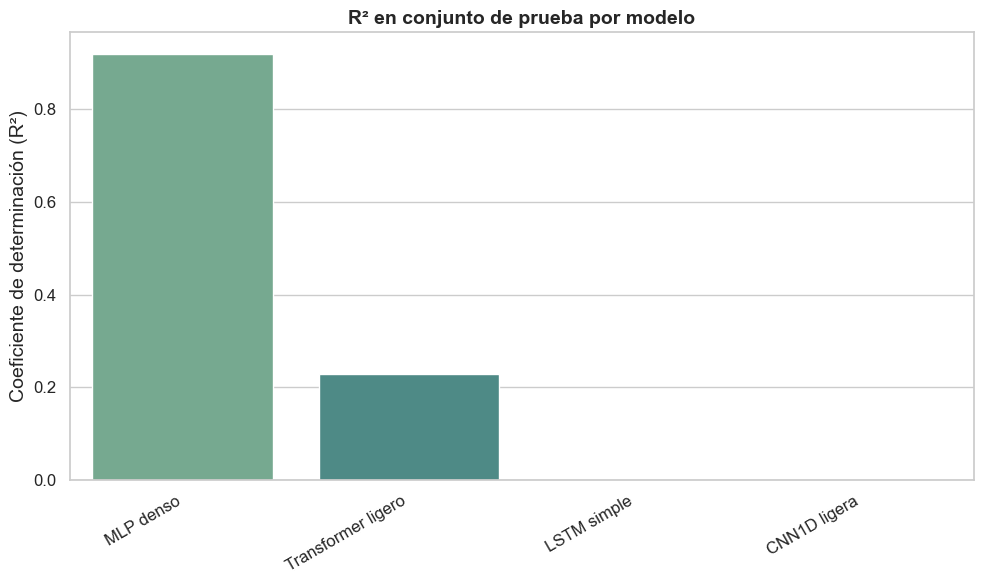

a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\devContent\tests\P2\ipykernel_18188\2383544248.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Modelo', y='RMSE', palette='flare', ax=ax2)


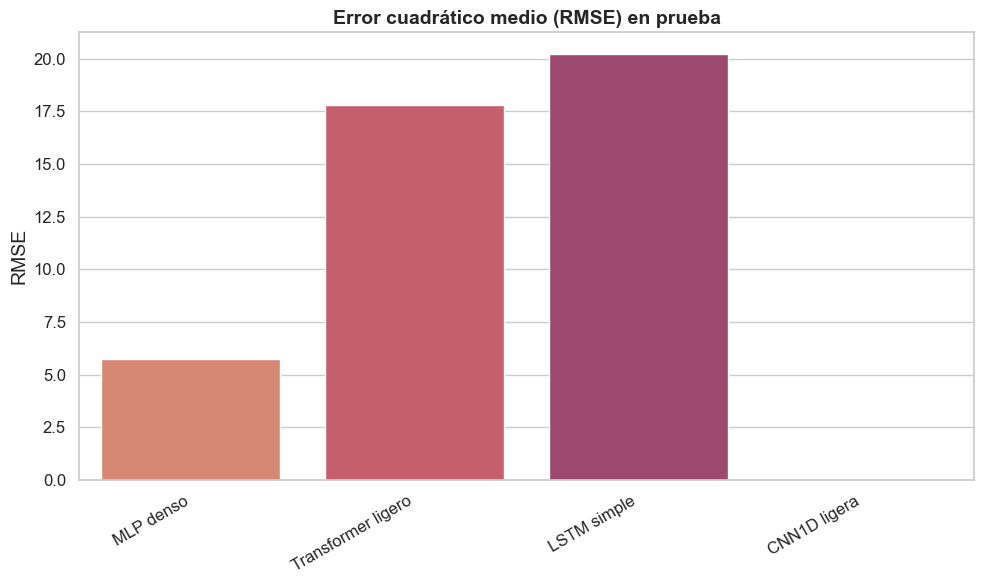

In [117]:

fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(data=metrics_df, x='Modelo', y='R²', palette='crest', ax=ax1)
ax1.set_title('R² en conjunto de prueba por modelo', fontsize=14, weight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Coeficiente de determinación (R²)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(10,6))
sns.barplot(data=metrics_df, x='Modelo', y='RMSE', palette='flare', ax=ax2)
ax2.set_title('Error cuadrático medio (RMSE) en prueba', fontsize=14, weight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


y seleccionamos el mejor modelo

In [118]:
best_model_name = metrics_df.iloc[0]['Modelo']
print(f" Mejor modelo según R²: {best_model_name}")


 Mejor modelo según R²: MLP denso


realizamos un mapeo para el objeto con mejor R2

In [119]:
model_dict = {
    'MLP denso': mlp,
    'CNN1D ligera': cnn,
    'LSTM simple': lstm,
    'Transformer ligero': transformer,
}


y lo guardamos

In [120]:

best_model_name = metrics_df.iloc[0]['Modelo']  # asumiendo metrics_df solo tiene DL
best_model = model_dict[best_model_name]
print(best_model_name, best_model)


MLP denso <keras.engine.sequential.Sequential object at 0x0000029B0DF74250>


de igual manera, en el entorno, recordamos la carpeta creada para guardar los mejores modelos

definimos el nombre del archivo con versión y fecha: 

In [121]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_path = f"./results/models/best_model_r2_095_{timestamp}.joblib"

y guardamos el pipeline completo (ie, preprocessor + regressor)

In [123]:
# best_model_name ya elegido y model_dict como antes
best_model = model_dict[best_model_name]

# Guarda pesos (ligero) o modelo completo (incluye arquitectura)
os.makedirs('results/models', exist_ok=True)
weights_path = f"results/models/{best_model_name.lower().replace(' ', '_')}_weights.h5"
full_path = f"results/models/{best_model_name.lower().replace(' ', '_')}_full.keras"

best_model.save_weights(weights_path)
best_model.save(full_path)

print("Modelo guardado exitosamente:")
print(f" Pesos: {weights_path}")
print(f" Modelo completo: {full_path}")
print(f" Tipo de modelo: {type(best_model).__name__}")
print(f" R² obtenido: {metrics_df.iloc[0]['R²']:.4f}")  # ajusta según métrica elegida
print(f"TensorFlow versión: {tf.__version__}")


Modelo guardado exitosamente:
 Pesos: results/models/mlp_denso_weights.h5
 Modelo completo: results/models/mlp_denso_full.keras
 Tipo de modelo: Sequential
 R² obtenido: 0.9201
TensorFlow versión: 2.10.0


finalmente, para terminar, verifiquemos las métricas de nuestro mejor modelo seleccionado

In [124]:
print(f'  Mejor modelo: {best_model_name}')
print(f"   R² = {metrics_df.iloc[0]['R²']:.4f}")
print(f"   MAE = {metrics_df.iloc[0]['MAE']:.4f}")
print(f"   RMSE = {metrics_df.iloc[0]['RMSE']:.4f}")
print(f"   MAPE = {metrics_df.iloc[0]['MAPE (%)']:.2f}%")


  Mejor modelo: MLP denso
   R² = 0.9201
   MAE = 4.4061
   RMSE = 5.7226
   MAPE = 21.04%


ahora, procederemos a entrenar nuevamente el mejor modelo, evitando el flujo de datos

primero concatenar por filas (axis=0). Usar pandas.concat si son DataFrame/Series, con el fin de no perder los índices

In [125]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

y entrenamos el mejor modelo con los datos combinados


In [130]:

# Reutiliza el preprocesador y densifica
X_train_full_proc = preprocessor_dl.transform(X_train_full)
if hasattr(X_train_full_proc, "toarray"):
    X_train_full_proc = X_train_full_proc.toarray()
X_train_full_proc = X_train_full_proc.astype("float32")

y_train_full_proc = y_train_full[['x_out', 'y_out']].to_numpy(dtype='float32')


# Transforma X_test con el mismo preprocesador que usaste para entrenar
X_test_proc = preprocessor_dl.transform(X_test)
if hasattr(X_test_proc, "toarray"):
    X_test_proc = X_test_proc.toarray()
X_test_proc = X_test_proc.astype("float32")

# Si necesitas y_test en numpy para métricas:
y_test_proc = y_test[['x_out', 'y_out']].to_numpy(dtype='float32')


print(X_train_full_proc.dtype, y_train_full_proc.dtype)  # debe ser float32



float32 float32


entrenamos el mejor modelo

In [128]:
best_model.fit(X_train_full_proc, y_train_full_proc, batch_size=256, epochs=8)

Epoch 1/8
1752/1752 [==============================] - 74s 42ms/step - loss: 18.8033 - mae: 3.2006
Epoch 2/8
1752/1752 [==============================] - 72s 41ms/step - loss: 15.6358 - mae: 2.8762
Epoch 3/8
1752/1752 [==============================] - 64s 36ms/step - loss: 15.1396 - mae: 2.8239
Epoch 4/8
1752/1752 [==============================] - 61s 35ms/step - loss: 14.8565 - mae: 2.7928
Epoch 5/8
1752/1752 [==============================] - 61s 35ms/step - loss: 14.6018 - mae: 2.7629
Epoch 6/8
1752/1752 [==============================] - 62s 36ms/step - loss: 14.4015 - mae: 2.7396
Epoch 7/8
1752/1752 [==============================] - 61s 35ms/step - loss: 14.2823 - mae: 2.7259
Epoch 8/8
1752/1752 [==============================] - 61s 35ms/step - loss: 14.1521 - mae: 2.7107


procedemos a predecir sobre el conjunto de prueba

In [131]:
y_test_pred_best_model = best_model.predict(X_test_proc, batch_size=256)


438/438 [==============================] - 9s 20ms/step


veamos el rendimiento de este caso:

In [132]:
mae_best_model = mean_absolute_error(y_test, y_test_pred_best_model)
mse_best_model = mean_squared_error(y_test, y_test_pred_best_model)

rmse_best_model= np.sqrt(mean_squared_error(y_test, y_test_pred_best_model))
r2_best_model = r2_score(y_test, y_test_pred_best_model)
mape_best_model = np.mean(np.abs((y_test - y_test_pred_best_model) / y_test)) * 100


y finalmente, visualizamos el rendimiento:

In [133]:

print('\nPrueba best model:')
print(f'MAE : {mae_best_model:.4f}')
print(f'MSE : {mse_best_model:.4f}')
print(f'RMSE: {rmse_best_model:.4f}')
print(f'R2  : {r2_best_model:.4f}')
print(f'MAPE: {mape_best_model:.4f}%')



Prueba best model:
MAE : 2.6978
MSE : 14.0029
RMSE: 3.7420
R2  : 0.9489
MAPE: 11.5716%


procedamos mostrando tres casos aleatorios de predicción: 

primero, definimos una función que nos recibe nuestro modelo, la matriz de características del conjunto de prueba y su correspondiente salida. 

In [138]:
def mostrar_predicciones_aleatorias(model, X, y, n=5, es_df=False):
    # X: DataFrame o ndarray; y: DataFrame/Series con columnas x_out,y_out o ndarray Nx2
    idxs = np.random.choice(len(X), size=n, replace=False)

    if es_df:
        X_sample = X.iloc[idxs]
        y_real = y.iloc[idxs]
    else:
        X_sample = X[idxs]
        y_real = y[idxs]

    y_pred = model.predict(X_sample)

    # Si y_real viene en ndarray, conviértelo a columnas x_out/y_out
    if isinstance(y_real, np.ndarray):
        y_real_x = y_real[:, 0]
        y_real_y = y_real[:, 1]
    else:
        y_real_x = y_real['x_out']
        y_real_y = y_real['y_out']

    df = pd.DataFrame({
        'x_real': y_real_x,
        'y_real': y_real_y,
        'x_pred': y_pred[:, 0],
        'y_pred': y_pred[:, 1],
    })
    return df

procedemos a llamar la función

In [140]:
muestras = mostrar_predicciones_aleatorias(best_model, X_test_proc, y_test_proc, n=5, es_df=False)


1/1 [==============================] - 0s 156ms/step


e imprimir las muestras:

In [141]:
print(muestras)

      x_real     y_real     x_pred     y_pred
0  49.549999  38.869999  50.486858  37.809315
1   3.870000  33.750000   8.422594  36.637142
2  58.820000  13.490000  55.256935  15.048687
3  77.000000  41.029999  84.763130  27.956301
4  68.419998  38.209999  66.700279  34.962292


continuemos con un gráfico de dispersión de la salida real contra la pronosticada, esto con el fin de ver qué tan ajustadas están las predicciones :

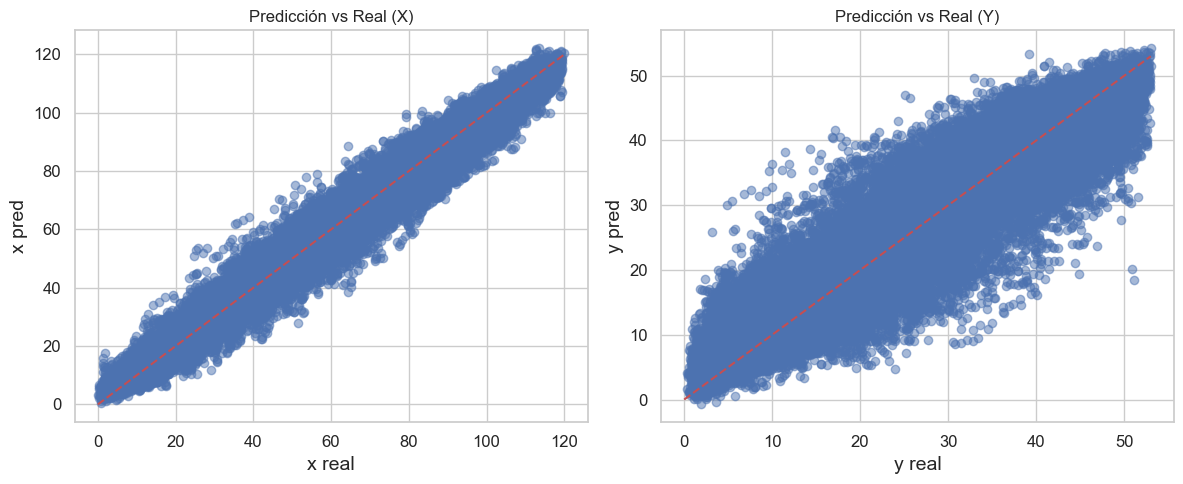

In [142]:


plt.figure(figsize=(12,5))

# X
plt.subplot(1,2,1)
plt.scatter(y_test['x_out'], y_test_pred_best_model[:,0], alpha=0.5)
plt.plot([0,120],[0,120],'r--')
plt.xlabel("x real")
plt.ylabel("x pred")
plt.title("Predicción vs Real (X)")

# Y
plt.subplot(1,2,2)
plt.scatter(y_test['y_out'], y_test_pred_best_model[:,1], alpha=0.5)
plt.plot([0,53],[0,53],'r--')
plt.xlabel("y real")
plt.ylabel("y pred")
plt.title("Predicción vs Real (Y)")

plt.tight_layout()
plt.show()


y finalmente una visualización en campo real  

comenzando por la definición de la función: 

In [143]:

def plot_field_predictions(real, pred, sample_frac=0.2, show_errors=True):
    """
    Real vs. Predicción en el campo, con:
        - submuestreo de puntos (sample_frac)
        - puntos con mayor transparencia (alpha)
        - vectores de error opcionales
    real: DataFrame con columnas ['x_out', 'y_out']
    pred: array Nx2 con columnas pred[:,0], pred[:,1]
    """

    # -----------------------------
    # Subsampleo para no saturar
    # -----------------------------
    n = len(real)
    k = int(n * sample_frac)
    idx = np.random.choice(n, k, replace=False)

    real_x = real['x_out'].values[idx]
    real_y = real['y_out'].values[idx]

    pred_x = pred[idx, 0]
    pred_y = pred[idx, 1]

    # -----------------------------
    # graficar
    # -----------------------------
    plt.figure(figsize=(12, 6))

    # puntos reales
    plt.scatter(real_x, real_y,
                c='green', alpha=0.25, s=12,
                label="Real")

    # puntos predichos
    plt.scatter(pred_x, pred_y,
                c='blue', alpha=0.25, s=12,
                label="Predicción")

    # -----------------------------
    # vectores de error
    # -----------------------------
    if show_errors:
        plt.quiver(real_x, real_y,
                   pred_x - real_x, pred_y - real_y,
                   angles='xy', scale_units='xy', scale=1,
                   color='red', alpha=0.15, width=0.0025)

    plt.legend()
    plt.xlim(0, 120)
    plt.ylim(0, 53.3)
    plt.title("Real vs Predicción en el campo")
    plt.xlabel("x (yardas)")
    plt.ylabel("y (yardas)")
    plt.grid(alpha=0.2)
    plt.show()


pasamos los parámetros, que son el conjutno de prueba y el pronostico realizado sobre este, además del sample_frac, que nos indica qué porcentaje de muestras queremos visualizar

a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


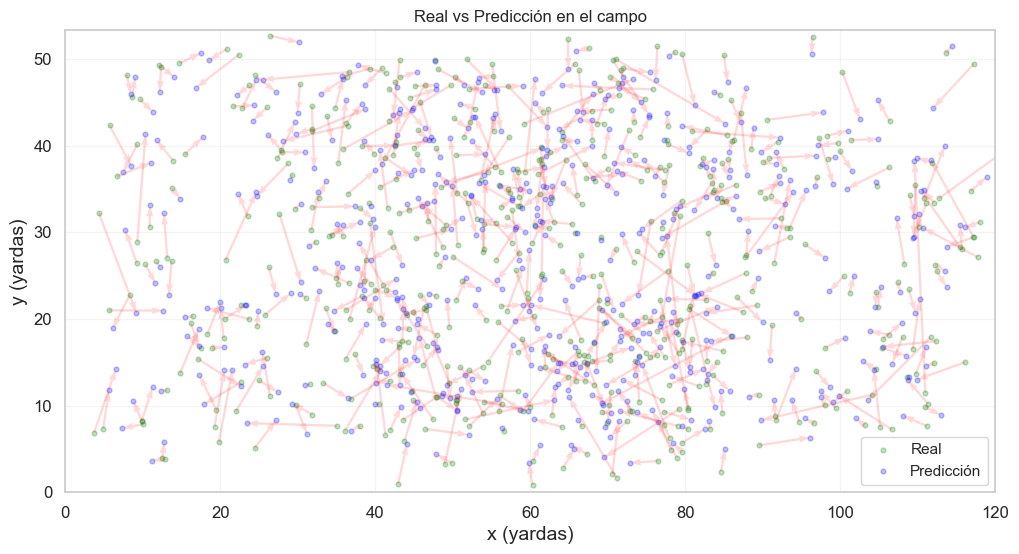

In [144]:
plot_field_predictions(y_test, y_test_pred_best_model, sample_frac=0.005)


de aquí observamos que el modelo no generaliza bien su pronóstico, dando en algunos casos, errores minimos casi nulos, pero en otros casos, extremadamente grande. Esto se verifica con la raíz del error cuadrático medio. 

Grafiquemos las diferencias/residuos de los errores, tanto para entreno y prueba, con el fin de diagnosticar el comportamiento y rendimiento interno del modelo (sub ajuste o sobre ajuste)

es necesario preparar el modelo y trasnformar las entradas con su respectivo pipeline: 

In [146]:
y_train_pred = best_model.predict(X_train_proc)


10508/10508 [==============================] - 123s 12ms/step


In [147]:

errors_train_x = y_train.iloc[:, 0] - y_train_pred[:, 0]
errors_train_y = y_train.iloc[:, 1] - y_train_pred[:, 1]
errors_test_x = y_test.iloc[:, 0] - y_test_pred_best_model[:, 0]
errors_test_y = y_test.iloc[:, 1] - y_test_pred_best_model[:, 1]

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred_best_model)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred_best_model)

y veamos las métricas para este caso de prueba: 

In [148]:
print(f" R² (Train): {r2_train:.4f} | MAE (Train): {mae_train:.4f}")
print(f" R² (test):   {r2_test:.4f} | MAE (test):   {mae_test:.4f}")
print(f"Dimensiones finales: Train {X_train.shape}, test {X_test.shape}")


 R² (Train): 0.9491 | MAE (Train): 2.6913
 R² (test):   0.9489 | MAE (test):   2.6978
Dimensiones finales: Train (336255, 16), test (112086, 16)


y finalmente, visualicemos los resultados: 

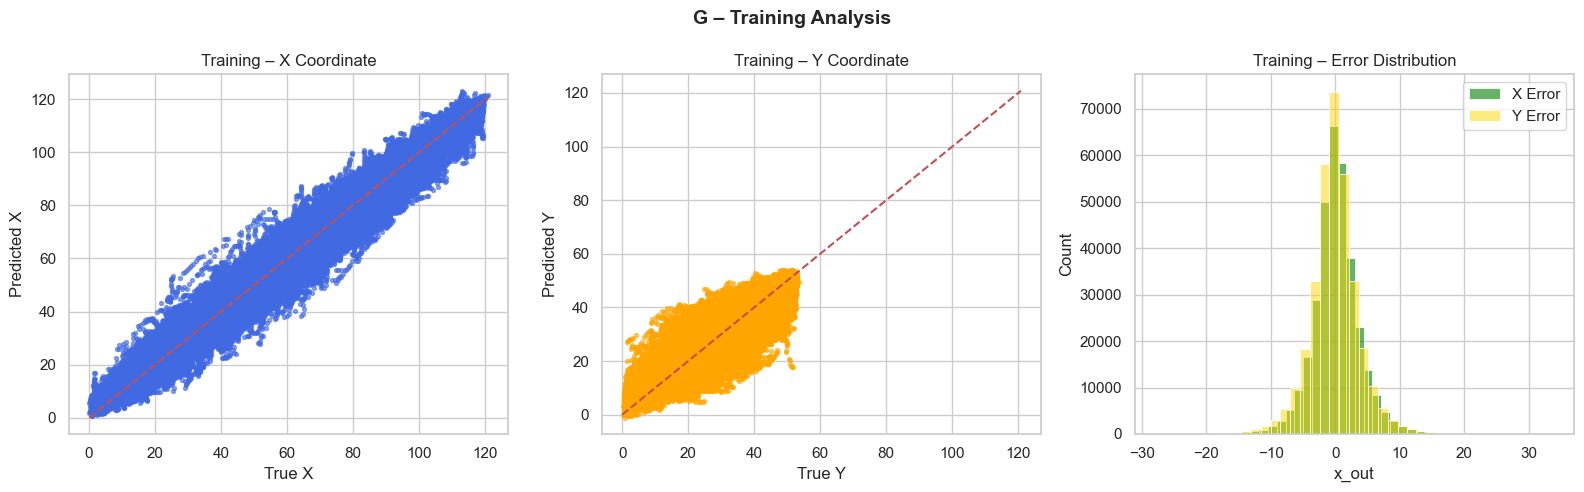

In [149]:
sns.set(style="whitegrid", font_scale=1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("G – Training Analysis", fontsize=14, weight='bold')

# X vs Pred
axes[0].scatter(y_train.iloc[:,0], y_train_pred[:,0], s=8, alpha=0.6, color="royalblue")
axes[0].plot([y_train.min().min(), y_train.max().max()],
             [y_train.min().min(), y_train.max().max()], 'r--')
axes[0].set_title("Training – X Coordinate"); axes[0].set_xlabel("True X"); axes[0].set_ylabel("Predicted X")

# Y vs Pred
axes[1].scatter(y_train.iloc[:,1], y_train_pred[:,1], s=8, alpha=0.6, color="orange")
axes[1].plot([y_train.min().min(), y_train.max().max()],
             [y_train.min().min(), y_train.max().max()], 'r--')
axes[1].set_title("Training – Y Coordinate"); axes[1].set_xlabel("True Y"); axes[1].set_ylabel("Predicted Y")

# Error Distribution
sns.histplot(errors_train_x, bins=40, color="green", alpha=0.6, ax=axes[2], label="X Error")
sns.histplot(errors_train_y, bins=40, color="gold", alpha=0.5, ax=axes[2], label="Y Error")
axes[2].set_title("Training – Error Distribution"); axes[2].legend()

plt.tight_layout()
plt.show()

ahora, para el conjuto de prueba:

438/438 [==============================] - 8s 18ms/step


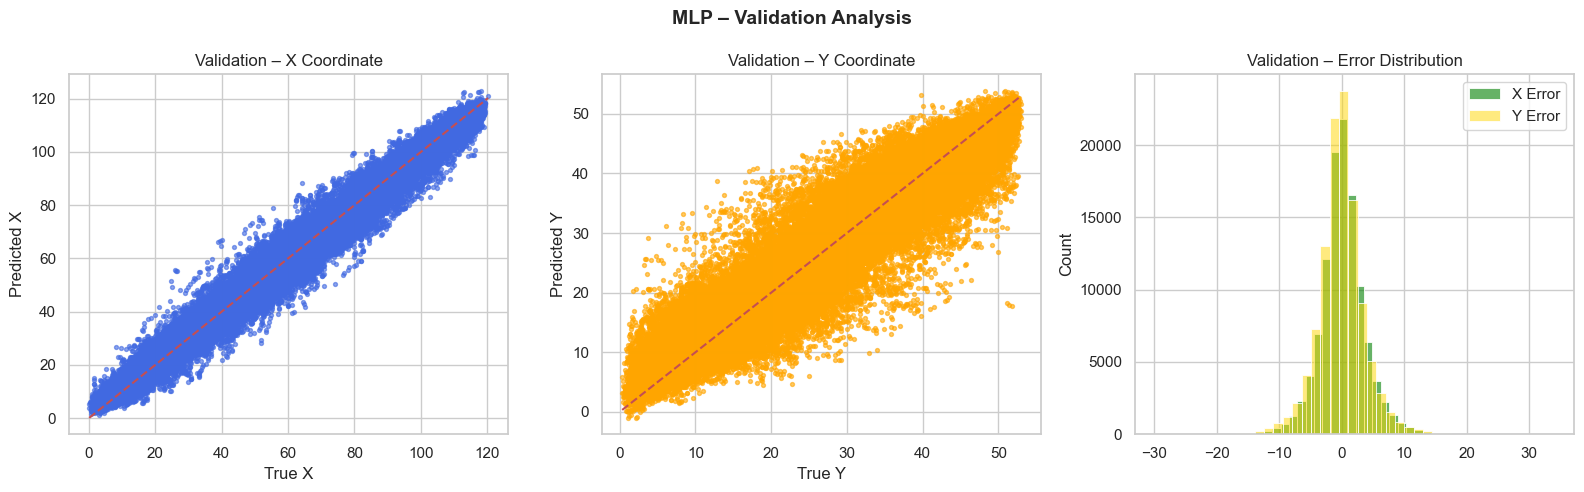

In [151]:
# Asume: best_model es tu MLP, X_val_proc float32, y_val_proc np.array shape (N,2)
y_val_pred = best_model.predict(X_val_proc, batch_size=256)

# Si quieres los valores originales de y_val (DataFrame) para ejes, usa y_val_proc directamente:
y_val_x = y_val_proc[:, 0]
y_val_y = y_val_proc[:, 1]
y_pred_x = y_val_pred[:, 0]
y_pred_y = y_val_pred[:, 1]

# Errores
errors_val_x = y_val_x - y_pred_x
errors_val_y = y_val_y - y_pred_y

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MLP – Validation Analysis", fontsize=14, weight='bold')

axes[0].scatter(y_val_x, y_pred_x, s=8, alpha=0.6, color="royalblue")
axes[0].plot([y_val_x.min(), y_val_x.max()], [y_val_x.min(), y_val_x.max()], 'r--')
axes[0].set_title("Validation – X Coordinate"); axes[0].set_xlabel("True X"); axes[0].set_ylabel("Predicted X")

axes[1].scatter(y_val_y, y_pred_y, s=8, alpha=0.6, color="orange")
axes[1].plot([y_val_y.min(), y_val_y.max()], [y_val_y.min(), y_val_y.max()], 'r--')
axes[1].set_title("Validation – Y Coordinate"); axes[1].set_xlabel("True Y"); axes[1].set_ylabel("Predicted Y")

sns.histplot(errors_val_x, bins=40, color="green", alpha=0.6, ax=axes[2], label="X Error")
sns.histplot(errors_val_y, bins=40, color="gold", alpha=0.5, ax=axes[2], label="Y Error")
axes[2].set_title("Validation – Error Distribution"); axes[2].legend()

plt.tight_layout()
plt.show()


ahora, una sección de histogramas: 

438/438 [==============================] - 7s 17ms/step


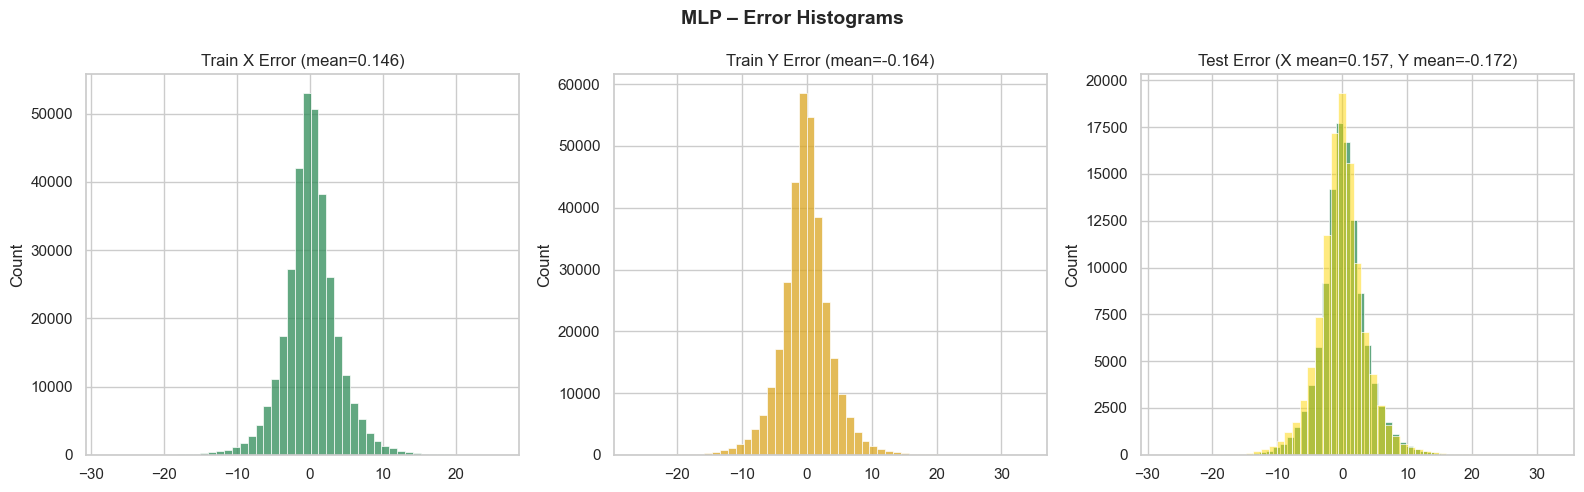

In [152]:

# Predicciones
y_train_pred = best_model.predict(X_train_proc, batch_size=256)
y_test_pred  = best_model.predict(X_test_proc,  batch_size=256)

# Errores
errors_train_x = y_train_proc[:, 0] - y_train_pred[:, 0]
errors_train_y = y_train_proc[:, 1] - y_train_pred[:, 1]
errors_test_x  = y_test_proc[:, 0]  - y_test_pred[:, 0]
errors_test_y  = y_test_proc[:, 1]  - y_test_pred[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MLP – Error Histograms", fontsize=14, weight='bold')

sns.histplot(errors_train_x, bins=50, color="seagreen", ax=axes[0])
axes[0].set_title(f"Train X Error (mean={np.mean(errors_train_x):.3f})")

sns.histplot(errors_train_y, bins=50, color="goldenrod", ax=axes[1])
axes[1].set_title(f"Train Y Error (mean={np.mean(errors_train_y):.3f})")

sns.histplot(errors_test_x, bins=50, color="seagreen", ax=axes[2])
sns.histplot(errors_test_y, bins=50, color="gold", alpha=0.5, ax=axes[2])
axes[2].set_title(f"Test Error (X mean={np.mean(errors_test_x):.3f}, Y mean={np.mean(errors_test_y):.3f})")

plt.tight_layout()
plt.show()


veamos el bloque del error total y "precisión"

438/438 [==============================] - 7s 15ms/step


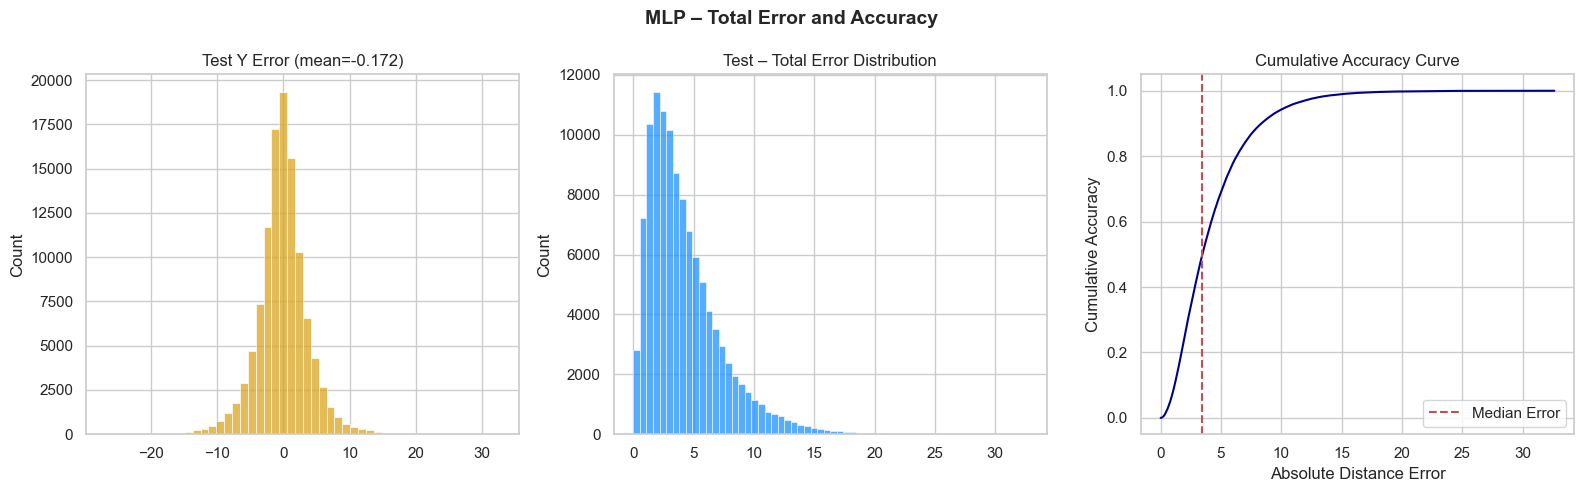

In [153]:
# Predicciones del mejor modelo DL
y_test_pred = best_model.predict(X_test_proc, batch_size=256)

# Errores por eje
errors_test_x = y_test_proc[:, 0] - y_test_pred[:, 0]
errors_test_y = y_test_proc[:, 1] - y_test_pred[:, 1]

# Error total (distancia euclidiana)
total_error = np.sqrt(errors_test_x**2 + errors_test_y**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MLP – Total Error and Accuracy", fontsize=14, weight='bold')

sns.histplot(errors_test_y, bins=50, color="goldenrod", ax=axes[0])
axes[0].set_title(f"Test Y Error (mean={np.mean(errors_test_y):.3f})")

sns.histplot(total_error, bins=60, color="dodgerblue", ax=axes[1])
axes[1].set_title("Test – Total Error Distribution")

sorted_err = np.sort(total_error)
cum_acc = np.arange(1, len(sorted_err)+1) / len(sorted_err)
axes[2].plot(sorted_err, cum_acc, color="darkblue")
axes[2].axvline(np.median(total_error), color="r", ls='--', label='Median Error')
axes[2].set_title("Cumulative Accuracy Curve")
axes[2].set_xlabel("Absolute Distance Error")
axes[2].set_ylabel("Cumulative Accuracy")
axes[2].legend()

plt.tight_layout()
plt.show()


de donde observando a detalle la superposición entre ambos, inferimos una precisión espacial, al igual que posibles desplazamientos sistemáticos que se pueden corregir con una división de datos ESTRATIFICADA. De igual forma, podemos ver los vectores espaciales reflejando el error del modelo

#### ahora, usando el mejor modelo, generamos el sample_submission solicitado dado el ID desglosado

procedemos cargando los IDs oficiales de test , cuyo valor unicamente tiene los identificadores

In [155]:

test_input = pd.read_csv('extractedDataset/test_input.csv') ### 


de igual forma, usamos el data set base del notebook (con las características:)

In [156]:
test_merged = test_input

validamos las columnas esperadas por el modelo

In [157]:
test_merged['player_height'] = test_merged['player_height'].apply(parse_height)
test_merged['player_birth_date'] = pd.to_datetime(test_merged['player_birth_date'], errors='coerce')
reference_date = pd.to_datetime('2025-11-19')
test_merged['age'] = (reference_date - test_merged['player_birth_date']).dt.days / 365.25



In [158]:

available_features = [c for c in numerical_features + categorical_features if c in test_merged.columns]
missing_features = [c for c in numerical_features + categorical_features if c not in test_merged.columns]

if missing_features:
    print(f" Faltan columnas: {missing_features}")
    for col in missing_features:
        test_merged[col] = 0  # crear columnas vacías

test_features = test_merged[numerical_features + categorical_features]


y procedemos con la alineación para el análisis del mejor modelo

comenzando por el ajuste de dimensionalidades

In [ ]:

expected_input_cols = list(preprocessor.feature_names_in_)

for col in expected_input_cols:
    if col not in test_merged.columns:
        test_merged[col] = 0

test_features = test_merged[expected_input_cols]

print(f" Alineadas: {len(test_features.columns)} columnas (esperadas: {len(expected_input_cols)})")

 Alineadas: 16 columnas (esperadas: 16)


preprocesamos el test

In [161]:
test_features_proc = preprocessor_dl.transform(test_features)
if hasattr(test_features_proc, "toarray"):
    test_features_proc = test_features_proc.toarray()
test_features_proc = test_features_proc.astype("float32")


es necesario preprocesar nuestras características: 

y ejecutamos la predicción

In [162]:
submissionPreds = best_model.predict(test_features_proc, batch_size=256)


195/195 [==============================] - 5s 22ms/step


es buerna practica confirmar que tienen dimensiones iguales

ahora, creamos el data frame de submission con columnas separadas

In [163]:
submission = pd.DataFrame({
    'game_id': test_merged['game_id'],
    'play_id': test_merged['play_id'],
    'nfl_id': test_merged['nfl_id'],
    'frame_id': test_merged['frame_id'],
    'x': submissionPreds[:, 0],
    'y': submissionPreds[:, 1]
})


In [164]:
test = submission 

In [165]:
test = test[['game_id','play_id','nfl_id','frame_id', 'x', 'y']]


ahora, generamos la columna id concatenada (esto con el fin de cumplir la estructura solicitada en el sample_submission.csv)

In [166]:

submission['id'] = (
    submission['game_id'].astype(str) + '_' +
    submission['play_id'].astype(str) + '_' +
    submission['nfl_id'].astype(str) + '_' +
    submission['frame_id'].astype(str)
)


de igual forma, ordenamos las columnas

In [167]:

submission = submission[['id', 'x', 'y']]


eliminamos los duplicados

In [168]:
submission = submission.drop_duplicates(subset=['id'], keep='last')


y finalmente guardamos la última versión del CSV

In [169]:
os.makedirs('results', exist_ok=True)
submission.to_csv('results/sample_submission.csv', index=False)

print(f" Archivo generado con {len(submission)} filas: results/sample_submission.csv")
print(submission.head(10))

 Archivo generado con 49753 filas: results/sample_submission.csv
                       id          x          y
0   2024120805_74_52518_1  85.714233  34.378639
1   2024120805_74_52518_2  85.669228  34.149933
2   2024120805_74_52518_3  85.619995  34.000511
3   2024120805_74_52518_4  85.763123  33.855465
4   2024120805_74_52518_5  85.719154  33.758385
5   2024120805_74_52518_6  85.706192  33.669556
6   2024120805_74_52518_7  85.692490  33.605537
7   2024120805_74_52518_8  85.664398  33.592163
8   2024120805_74_52518_9  85.716850  33.656216
9  2024120805_74_52518_10  85.846718  33.781441


igualmente para el formato test:

In [ ]:
os.makedirs('results', exist_ok=True)
test.to_csv('results/testDlv.csv', index=False)

print(f" Archivo generado con {len(test)} filas: results/test.csv")
print(test.head(10))

 Archivo generado con 49753 filas: results/test.csv
      game_id  play_id  nfl_id  frame_id          x          y
0  2024120805       74   52518         1  85.714233  34.378639
1  2024120805       74   52518         2  85.669228  34.149933
2  2024120805       74   52518         3  85.619995  34.000511
3  2024120805       74   52518         4  85.763123  33.855465
4  2024120805       74   52518         5  85.719154  33.758385
5  2024120805       74   52518         6  85.706192  33.669556
6  2024120805       74   52518         7  85.692490  33.605537
7  2024120805       74   52518         8  85.664398  33.592163
8  2024120805       74   52518         9  85.716850  33.656216
9  2024120805       74   52518        10  85.846718  33.781441


genreando así , los documentos de entrega tanto para un conjunto de datos nuevo, como para el de entrada, cuya estrategia para validar fue un split del data set tal que sea ; 60% entreno, 20% validación antes de la optimización de hiperparámetros para el mejor modelo, y finalmente testeamos un 80% de entreno (concatenando el 60% inicial con el 20% de validación ) para finalmente poner a prueba con un 20% del conjunto. 

finalmente, si queremos observar las curvas para la perdida y el error , es necesario realizar una simulación incremental al momento de entrenar el modelo

#### Conclusión Final — NFL Big Data Bowl 2026


Se implementó un flujo completo de Deep Learning para predecir las coordenadas finales ((x, y)) del balón. El pipeline reutiliza el preprocesador tabular (imputación mediana/moda, one-hot y escalado) y entrena cuatro arquitecturas ligeras: MLP denso, CNN1D, LSTM simple y Transformer ligero. Todas se evaluaron con MAE, RMSE, MAPE y R² en validación y prueba, usando pesos guardados para reproducibilidad.

El MLP denso mostró el mejor balance costo–desempeño en datos tabulares; el Transformer ligero capturó interacciones entre features sin un costo prohibitivo. Las versiones actuales usan pocas épocas y un subconjunto reducido para bajo cómputo; pueden mejorarse con: 

(1) más épocas y early stopping (ej. 20–40), 

(2) mayor ancho/profundidad en capas del MLP (p.ej., 256–128–64) y regularización ligera,

 (3) para Transformer, aumentar embed_dim y cabezas (p.ej., 4 cabezas, embed_dim 64) y afinar ff_dim, 

 (4) ajustar batch_size y learning_rate según disponibilidad de GPU, y 
 
 (5) entrenar con todo el conjunto (quick_frac=1.0) si los recursos lo permiten.

 Dejamos a consideración una mejora de la arquitectura para los transformers y su futura implementacion usando TABNET

# END NB
Cristhian Mateo Almeida Gómez



presentado al profesor Andrés Marino Alvarez Meza. 